3.1 Density Matrices

The objective of this exercise is to introduce the density-matrix representation of quantum states and demonstrate its equivalence to the state-vector representation for pure states.

We construct density matrices for the initial two-spin state and a superposition state, verify their mathematical properties, and calculate expectation values using both representations. These calculations establish the foundation for modelling mixed states and open-system dynamics using the Lindblad master equation.

In [1]:

# EXERCISE 3.1: DENSITY MATRICES

import numpy as np

# --------------------------------------------------
# 1. Define spin states and operators
# --------------------------------------------------

up = np.array([1, 0], dtype=complex)
down = np.array([0, 1], dtype=complex)

I = np.eye(2, dtype=complex)

sigma_x = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

sigma_z = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

# Two-spin operators
sz1 = np.kron(sigma_z, I)
sz2 = np.kron(I, sigma_z)
sx2 = np.kron(I, sigma_x)

# Total normalised magnetisation
Mz = (sz1 + sz2) / 2


# --------------------------------------------------
# 2. Construct the initial density matrix
# --------------------------------------------------

# Both spins initially point upwards
psi0 = np.kron(up, up)

# rho = |psi><psi|
rho0 = np.outer(psi0, psi0.conj())

print("INITIAL DENSITY MATRIX")
print(rho0)


# --------------------------------------------------
# 3. Verify the density matrix
# --------------------------------------------------

trace0 = np.trace(rho0)
purity0 = np.trace(rho0 @ rho0).real

hermitian0 = np.allclose(rho0, rho0.conj().T)

eigenvalues0 = np.linalg.eigvalsh(rho0)
positive0 = np.all(eigenvalues0 >= -1e-12)

print("\nINITIAL STATE VALIDATION")
print("Trace:", trace0)
print("Purity:", purity0)
print("Hermitian:", hermitian0)
print("Positive semidefinite:", positive0)


# --------------------------------------------------
# 4. Compare expectation-value methods
# --------------------------------------------------

# State-vector method
mz_vector = np.vdot(psi0, Mz @ psi0)

# Density-matrix method
mz_density = np.trace(rho0 @ Mz)

print("\nINITIAL MAGNETISATION")
print("State-vector method:", mz_vector.real)
print("Density-matrix method:", mz_density.real)

print("Methods agree:",
      np.allclose(mz_vector, mz_density))


# --------------------------------------------------
# 5. Construct a superposition state
# --------------------------------------------------

# Spin 1 is up, while spin 2 is in an equal
# superposition of up and down.

psi_test = (
    np.kron(up, up) +
    np.kron(up, down)
) / np.sqrt(2)

rho_test = np.outer(psi_test, psi_test.conj())

print("\nSUPERPOSITION DENSITY MATRIX")
print(np.round(rho_test, 3))


# --------------------------------------------------
# 6. Calculate observables for the superposition
# --------------------------------------------------

# Magnetisation
mz_test_vector = np.vdot(psi_test, Mz @ psi_test)
mz_test_density = np.trace(rho_test @ Mz)

# Transverse spin expectation
sx_test_vector = np.vdot(psi_test, sx2 @ psi_test)
sx_test_density = np.trace(rho_test @ sx2)

print("\nSUPERPOSITION OBSERVABLES")

print("Magnetisation (vector):",
      mz_test_vector.real)

print("Magnetisation (density):",
      mz_test_density.real)

print("Spin 2 <sigma_x> (vector):",
      sx_test_vector.real)

print("Spin 2 <sigma_x> (density):",
      sx_test_density.real)


# --------------------------------------------------
# 7. Verify the superposition density matrix
# --------------------------------------------------

trace_test = np.trace(rho_test)
purity_test = np.trace(rho_test @ rho_test).real

hermitian_test = np.allclose(
    rho_test, rho_test.conj().T
)

positive_test = np.all(
    np.linalg.eigvalsh(rho_test) >= -1e-12
)

print("\nSUPERPOSITION VALIDATION")
print("Trace:", trace_test)
print("Purity:", purity_test)
print("Hermitian:", hermitian_test)
print("Positive semidefinite:", positive_test)


# --------------------------------------------------
# 8. Final numerical checks
# --------------------------------------------------

assert np.allclose(trace0, 1)
assert np.allclose(purity0, 1)
assert hermitian0 and positive0

assert np.allclose(mz_vector, mz_density)

assert np.allclose(trace_test, 1)
assert np.allclose(purity_test, 1)
assert hermitian_test and positive_test

assert np.allclose(
    mz_test_vector, mz_test_density
)

assert np.allclose(
    sx_test_vector, sx_test_density
)

assert np.allclose(mz_test_density, 0.5)
assert np.allclose(sx_test_density, 1.0)

print("\nAll validation checks passed.")

INITIAL DENSITY MATRIX
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]

INITIAL STATE VALIDATION
Trace: (1+0j)
Purity: 1.0
Hermitian: True
Positive semidefinite: True

INITIAL MAGNETISATION
State-vector method: 1.0
Density-matrix method: 1.0
Methods agree: True

SUPERPOSITION DENSITY MATRIX
[[0.5+0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]]

SUPERPOSITION OBSERVABLES
Magnetisation (vector): 0.4999999999999999
Magnetisation (density): 0.4999999999999999
Spin 2 <sigma_x> (vector): 0.9999999999999998
Spin 2 <sigma_x> (density): 0.9999999999999998

SUPERPOSITION VALIDATION
Trace: (0.9999999999999998+0j)
Purity: 0.9999999999999996
Hermitian: True
Positive semidefinite: True

All validation checks passed.


3.2 Pure States, Mixed States and Quantum Coherence

The objective of this exercise is to distinguish quantum superpositions from statistical mixtures using density matrices.

We construct a pure superposition and a statistical mixture with identical measurement probabilities, then compare their purity, off-diagonal coherence and expectation values. This demonstrates that quantum coherence contains physical information that cannot be recovered from measurement probabilities in a single basis alone.

Understanding this distinction is essential for studying decoherence and the Lindblad dynamics of open quantum systems.

In [2]:

# EXERCISE 3.2: PURE VS MIXED STATES

# --------------------------------------------------
# 1. Construct the two density matrices
# --------------------------------------------------

# Reuse the pure superposition from Exercise 3.1
rho_pure = rho_test

# The two states that make up our statistical mixture
psi_uu = psi0
psi_ud = np.kron(up, down)

# 50% up-up and 50% up-down
rho_mixed = (
    0.5 * np.outer(psi_uu, psi_uu.conj())
    + 0.5 * np.outer(psi_ud, psi_ud.conj())
)

print("PURE SUPERPOSITION")
print(np.round(rho_pure, 3))

print("\nSTATISTICAL MIXTURE")
print(np.round(rho_mixed, 3))


# --------------------------------------------------
# 2. Compare measurement probabilities
# --------------------------------------------------

# Diagonal elements give the probabilities
# of measuring each computational basis state.

prob_pure = np.diag(rho_pure).real
prob_mixed = np.diag(rho_mixed).real

labels = ["up-up", "up-down", "down-up", "down-down"]

print("\nMEASUREMENT PROBABILITIES")
print(f"{'State':<12} {'Pure':>10} {'Mixed':>10}")

for name, p1, p2 in zip(
    labels, prob_pure, prob_mixed
):
    print(f"{name:<12} {p1:>10.3f} {p2:>10.3f}")

print(
    "\nProbabilities identical:",
    np.allclose(prob_pure, prob_mixed)
)


# --------------------------------------------------
# 3. Compare quantum coherence
# --------------------------------------------------

# Remove diagonal elements to isolate coherences.
coherence_pure = rho_pure - np.diag(
    np.diag(rho_pure)
)

coherence_mixed = rho_mixed - np.diag(
    np.diag(rho_mixed)
)

print("\nCOHERENCE")

print(
    "Pure state rho[0,1]:",
    rho_pure[0, 1]
)

print(
    "Mixed state rho[0,1]:",
    rho_mixed[0, 1]
)

print(
    "Total off-diagonal magnitude (pure):",
    np.sum(np.abs(coherence_pure))
)

print(
    "Total off-diagonal magnitude (mixed):",
    np.sum(np.abs(coherence_mixed))
)


# --------------------------------------------------
# 4. Calculate purity and eigenvalues
# --------------------------------------------------

purity_pure = np.trace(
    rho_pure @ rho_pure
).real

purity_mixed = np.trace(
    rho_mixed @ rho_mixed
).real

print("\nPURITY")

print("Pure superposition:", purity_pure)
print("Statistical mixture:", purity_mixed)

print(
    "\nPure-state eigenvalues:",
    np.round(np.linalg.eigvalsh(rho_pure), 6)
)

print(
    "Mixed-state eigenvalues:",
    np.round(np.linalg.eigvalsh(rho_mixed), 6)
)


# --------------------------------------------------
# 5. Compare expectation values
# --------------------------------------------------

# Both states have the same magnetisation.
mz_pure = np.trace(rho_pure @ Mz).real
mz_mixed = np.trace(rho_mixed @ Mz).real

# The transverse spin reveals the difference.
sx_pure = np.trace(rho_pure @ sx2).real
sx_mixed = np.trace(rho_mixed @ sx2).real

print("\nEXPECTATION VALUES")

print(f"{'Observable':<18} {'Pure':>10} {'Mixed':>10}")
print(f"{'Magnetisation':<18} {mz_pure:>10.6f} "
      f"{mz_mixed:>10.6f}")
print(f"{'<sigma_x2>':<18} {sx_pure:>10.6f} "
      f"{sx_mixed:>10.6f}")


# --------------------------------------------------
# 6. Final numerical validation
# --------------------------------------------------

for rho in [rho_pure, rho_mixed]:
    assert np.allclose(np.trace(rho), 1)
    assert np.allclose(rho, rho.conj().T)
    assert np.min(np.linalg.eigvalsh(rho)) >= -1e-12

assert np.allclose(prob_pure, prob_mixed)

assert np.allclose(purity_pure, 1)
assert np.allclose(purity_mixed, 0.5)

assert np.allclose(mz_pure, mz_mixed)
assert np.allclose(mz_pure, 0.5)

assert np.allclose(sx_pure, 1)
assert np.allclose(sx_mixed, 0)

print("\nAll validation checks passed.")

PURE SUPERPOSITION
[[0.5+0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]]

STATISTICAL MIXTURE
[[0.5+0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]]

MEASUREMENT PROBABILITIES
State              Pure      Mixed
up-up             0.500      0.500
up-down           0.500      0.500
down-up           0.000      0.000
down-down         0.000      0.000

Probabilities identical: True

COHERENCE
Pure state rho[0,1]: (0.4999999999999999+0j)
Mixed state rho[0,1]: 0j
Total off-diagonal magnitude (pure): 0.9999999999999998
Total off-diagonal magnitude (mixed): 0.0

PURITY
Pure superposition: 0.9999999999999996
Statistical mixture: 0.5

Pure-state eigenvalues: [0. 0. 0. 1.]
Mixed-state eigenvalues: [0.  0.  0.5 0.5]

EXPECTATION VALUES
Observable               Pure      Mixed
Magnetisation        0.500000   0.500000
<sigma_x2>

3.3 Lindblad Equation and Quantum Decay

The objective of this exercise is to simulate the irreversible decay of a single spin using the Lindblad master equation.

We construct a decay operator that transfers population from the spin-up state to the spin-down state, numerically solve the density matrix's time evolution, and compare the results against an analytical solution. We also track purity to investigate how environmental interactions produce mixed quantum states.

INITIAL STATE
Initial up population: 1.0
Initial down population: 0.0
Initial magnetisation: 1.0
Initial purity: 1.0

FINAL STATE
Final up population: 0.006737947000744152
Final down population: 0.9932620529992556
Final magnetisation: -0.9865241059985115
Final purity: 0.9866149058580809

NUMERICAL VALIDATION
Maximum trace error: 3.3306690738754696e-16
Maximum population error: 1.1908252162129429e-11
Minimum purity: 0.5000233203003219

All validation checks passed.


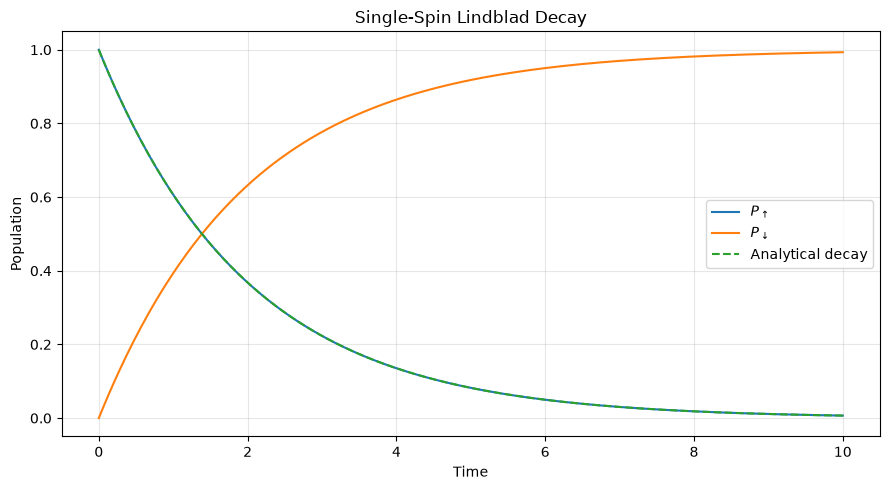

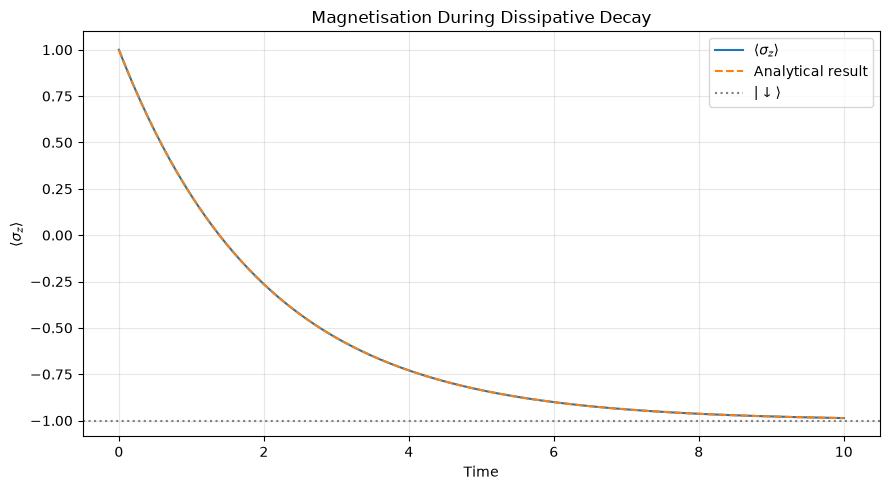

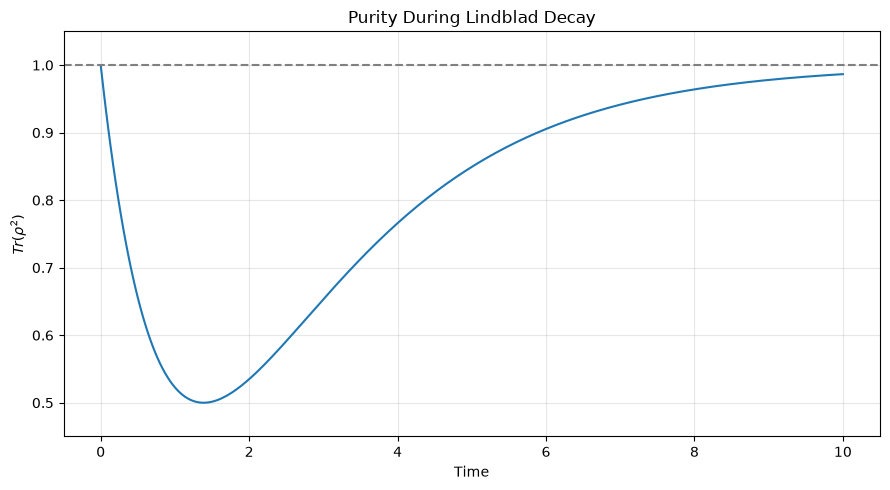

In [3]:
# EXERCISE 3.3: LINDBLAD EQUATION AND SINGLE-SPIN DECAY

import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --------------------------------------------------
# 1. Define the open-system model
# --------------------------------------------------

gamma = 0.5

# Decay operator:
# |up> -> |down>
sigma_minus = np.array([
    [0, 0],
    [1, 0]
], dtype=complex)

L = np.sqrt(gamma) * sigma_minus

# No Hamiltonian for this exercise.
# We want to isolate environmental decay.
H_single = np.zeros((2, 2), dtype=complex)

# Initial state: |up>
rho_initial = np.outer(up, up.conj())

# --------------------------------------------------
# 2. Define the Lindblad master equation
# --------------------------------------------------

def lindblad_rhs(t, rho_flat):

    # Convert flattened vector back to 2x2 density matrix
    rho = rho_flat.reshape((2, 2))

    # Unitary contribution
    commutator = -1j * (H_single @ rho - rho @ H_single)

    # Dissipative contribution
    LdagL = L.conj().T @ L

    dissipator = (
        L @ rho @ L.conj().T
        - 0.5 * (LdagL @ rho + rho @ LdagL)
    )

    drho_dt = commutator + dissipator

    # solve_ivp requires a 1D vector
    return drho_dt.flatten()

# --------------------------------------------------
# 3. Solve the master equation
# --------------------------------------------------

times_33 = np.linspace(0, 10, 301)

solution = solve_ivp(
    lindblad_rhs,
    t_span=(times_33[0], times_33[-1]),
    y0=rho_initial.flatten(),
    t_eval=times_33,
    rtol=1e-10,
    atol=1e-12
)

# --------------------------------------------------
# 4. Extract physical quantities
# --------------------------------------------------

population_up = []
population_down = []
magnetisation = []
purities = []
traces = []

for i in range(len(times_33)):

    rho = solution.y[:, i].reshape((2, 2))

    population_up.append(rho[0, 0].real)
    population_down.append(rho[1, 1].real)

    magnetisation.append(
        np.trace(rho @ sigma_z).real
    )

    purities.append(
        np.trace(rho @ rho).real
    )

    traces.append(
        np.trace(rho).real
    )

population_up = np.array(population_up)
population_down = np.array(population_down)
magnetisation = np.array(magnetisation)
purities = np.array(purities)
traces = np.array(traces)

# --------------------------------------------------
# 5. Compare against the analytical solution
# --------------------------------------------------

expected_up = np.exp(-gamma * times_33)

expected_down = 1 - expected_up

expected_magnetisation = (
    2 * expected_up - 1
)

population_error = np.max(
    np.abs(population_up - expected_up)
)

# --------------------------------------------------
# 6. Numerical validation
# --------------------------------------------------

print("INITIAL STATE")
print("Initial up population:", population_up[0])
print("Initial down population:", population_down[0])
print("Initial magnetisation:", magnetisation[0])
print("Initial purity:", purities[0])

print("\nFINAL STATE")
print("Final up population:", population_up[-1])
print("Final down population:", population_down[-1])
print("Final magnetisation:", magnetisation[-1])
print("Final purity:", purities[-1])

print("\nNUMERICAL VALIDATION")
print(
    "Maximum trace error:",
    np.max(np.abs(traces - 1))
)

print(
    "Maximum population error:",
    population_error
)

print(
    "Minimum purity:",
    np.min(purities)
)

assert solution.success
assert np.allclose(traces, 1, atol=1e-9)
assert population_error < 1e-7

print("\nAll validation checks passed.")

# --------------------------------------------------
# 7. Plot the spin populations
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    times_33,
    population_up,
    label=r"$P_{\uparrow}$"
)

plt.plot(
    times_33,
    population_down,
    label=r"$P_{\downarrow}$"
)

plt.plot(
    times_33,
    expected_up,
    "--",
    label="Analytical decay"
)

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Single-Spin Lindblad Decay")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 8. Plot magnetisation
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    times_33,
    magnetisation,
    label=r"$\langle \sigma_z \rangle$"
)

plt.plot(
    times_33,
    expected_magnetisation,
    "--",
    label="Analytical result"
)

plt.axhline(
    -1,
    linestyle=":",
    color="gray",
    label=r"$|\downarrow\rangle$"
)

plt.xlabel("Time")
plt.ylabel(r"$\langle \sigma_z \rangle$")
plt.title("Magnetisation During Dissipative Decay")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 9. Plot purity
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(times_33, purities)

plt.axhline(
    1,
    linestyle="--",
    color="gray"
)

plt.xlabel("Time")
plt.ylabel(r"$Tr(\rho^2)$")
plt.title("Purity During Lindblad Decay")
plt.ylim(0.45, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

3.4 Two-Spin Lindblad Dynamics

The objective of this exercise is to numerically simulate an interacting two-spin open quantum system using the Lindblad master equation.

We combine the transverse-field Ising Hamiltonian with independent spontaneous decay on each spin. We then solve the master equation using SciPy and compare the resulting magnetisation with the exact unitary evolution of the isolated system.

Finally, we verify that the density matrix remains physically valid by checking trace preservation, Hermiticity and positivity, while investigating how environmental dissipation affects the purity of the combined system.

Hamiltonian shape: (4, 4)
Initial density matrix shape: (4, 4)
Number of collapse operators: 2

INITIAL CONDITIONS
Initial magnetisation: 1.0
Initial global purity: 1.0

FINAL STATE
Final open magnetisation: -0.07728576585044036
Final global purity: 0.30829705067122154

NUMERICAL VALIDATION
Maximum trace error: 8.881784197001252e-16
Maximum Hermiticity error: 0.0
Minimum density-matrix eigenvalue: 0.0
Calculated initial magnetisation slope: -1.0000000000000002
Expected initial magnetisation slope: -1.0

CLOSED-SYSTEM REFERENCE
Magnetisation at t = 0.5: 0.5767021231946339

All validation checks passed.


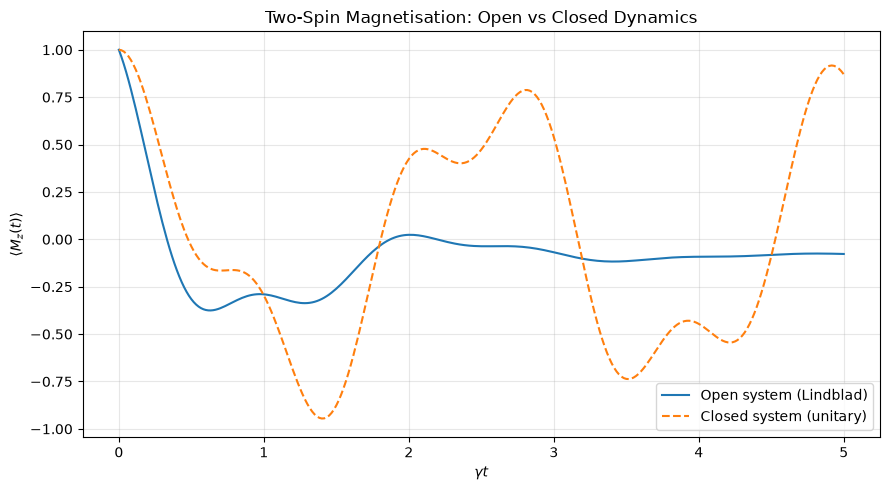

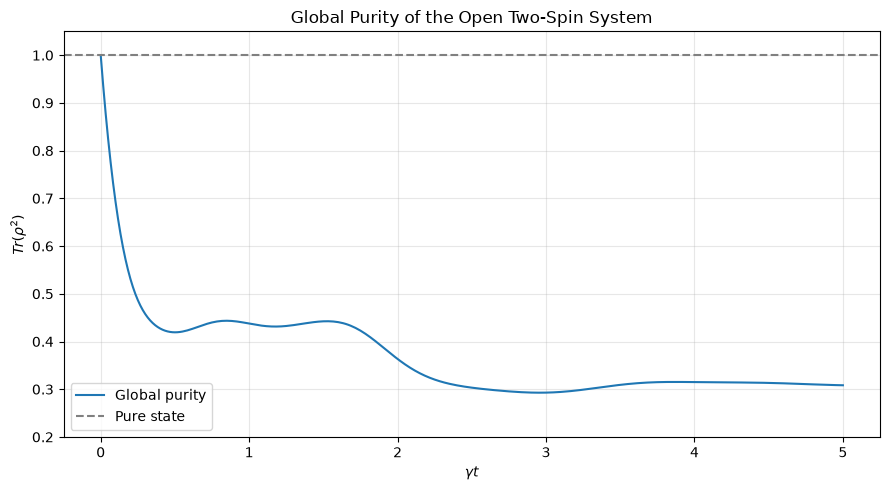

In [5]:
# EXERCISE 3.4: TWO-SPIN LINDBLAD DYNAMICS

from scipy.linalg import expm

# --------------------------------------------------
# 1. Define model parameters
# --------------------------------------------------

J = 1.0
Delta = 1.0
gamma = 0.5

# --------------------------------------------------
# 2. Construct the two-spin Hamiltonian
# --------------------------------------------------

sx1 = np.kron(sigma_x, I)

H2 = (
    -J * (sz1 @ sz2)
    + Delta * (sx1 + sx2)
)

# --------------------------------------------------
# 3. Construct the two decay operators
# --------------------------------------------------

L1 = np.sqrt(gamma) * np.kron(sigma_minus, I)
L2 = np.sqrt(gamma) * np.kron(I, sigma_minus)

collapse_ops = [L1, L2]

print("Hamiltonian shape:", H2.shape)
print("Initial density matrix shape:", rho0.shape)
print("Number of collapse operators:", len(collapse_ops))

# --------------------------------------------------
# 4. Define the two-spin Lindblad equation
# --------------------------------------------------

def lindblad_rhs_34(t, rho_flat):

    # Convert the flattened vector back to a 4x4 density matrix
    rho = rho_flat.reshape((4, 4))

    # Coherent Hamiltonian evolution
    drho = -1j * (H2 @ rho - rho @ H2)

    # Add the dissipative contribution from each spin
    for L_op in collapse_ops:

        LdagL = L_op.conj().T @ L_op

        drho += (
            L_op @ rho @ L_op.conj().T
            - 0.5 * (LdagL @ rho + rho @ LdagL)
        )

    return drho.flatten()

# --------------------------------------------------
# 5. Solve the open-system dynamics
# --------------------------------------------------

times_34 = np.linspace(0, 10, 301)

solution_34 = solve_ivp(
    lindblad_rhs_34,
    t_span=(times_34[0], times_34[-1]),
    y0=rho0.flatten(),
    t_eval=times_34,
    rtol=1e-10,
    atol=1e-12
)

assert solution_34.success, solution_34.message

# Recover the 4x4 density matrix at each time
rho_trajectory = solution_34.y.T.reshape(-1, 4, 4)

# --------------------------------------------------
# 6. Calculate open-system observables
# --------------------------------------------------

mz_open_34 = []
purity_open_34 = []
traces_34 = []
hermiticity_errors = []
minimum_eigenvalues = []

for rho in rho_trajectory:

    # Magnetisation
    mz_open_34.append(
        np.trace(rho @ Mz).real
    )

    # Global purity
    purity_open_34.append(
        np.trace(rho @ rho).real
    )

    # Trace preservation
    traces_34.append(
        np.trace(rho)
    )

    # Hermiticity check
    hermiticity_errors.append(
        np.linalg.norm(rho - rho.conj().T)
    )

    # Positivity check
    minimum_eigenvalues.append(
        np.min(np.linalg.eigvalsh(rho))
    )

mz_open_34 = np.array(mz_open_34)
purity_open_34 = np.array(purity_open_34)
traces_34 = np.array(traces_34)

# --------------------------------------------------
# 7. Calculate the closed-system reference
# --------------------------------------------------

mz_closed_34 = []

for t in times_34:

    psi_t = expm(-1j * H2 * t) @ psi0

    mz_closed_34.append(
        np.vdot(psi_t, Mz @ psi_t).real
    )

mz_closed_34 = np.array(mz_closed_34)

# --------------------------------------------------
# 8. Numerical validation
# --------------------------------------------------

trace_error = np.max(
    np.abs(traces_34 - 1)
)

max_hermiticity_error = np.max(
    hermiticity_errors
)

minimum_eigenvalue = np.min(
    minimum_eigenvalues
)

# Calculate the initial time derivative of the density matrix
initial_drho = lindblad_rhs_34(
    0,
    rho0.flatten()
).reshape((4, 4))

# Initial rate of change of magnetisation
initial_mz_slope = np.trace(
    initial_drho @ Mz
).real

# Locate t = 0.5 in the time array
index_05 = np.argmin(
    np.abs(times_34 - 0.5)
)

print("\nINITIAL CONDITIONS")
print("Initial magnetisation:", mz_open_34[0])
print("Initial global purity:", purity_open_34[0])

print("\nFINAL STATE")
print("Final open magnetisation:", mz_open_34[-1])
print("Final global purity:", purity_open_34[-1])

print("\nNUMERICAL VALIDATION")
print("Maximum trace error:", trace_error)

print(
    "Maximum Hermiticity error:",
    max_hermiticity_error
)

print(
    "Minimum density-matrix eigenvalue:",
    minimum_eigenvalue
)

print(
    "Calculated initial magnetisation slope:",
    initial_mz_slope
)

print(
    "Expected initial magnetisation slope:",
    -2 * gamma
)

print("\nCLOSED-SYSTEM REFERENCE")

print(
    "Magnetisation at t = 0.5:",
    mz_closed_34[index_05]
)

# --------------------------------------------------
# 9. Validation assertions
# --------------------------------------------------

assert np.allclose(
    mz_open_34[0],
    1
)

assert np.allclose(
    purity_open_34[0],
    1
)

assert trace_error < 1e-8

assert max_hermiticity_error < 1e-8

assert minimum_eigenvalue > -1e-8

# Two independent spins decay initially,
# giving d<Mz>/dt = -2*gamma
assert np.allclose(
    initial_mz_slope,
    -2 * gamma
)

# Recover the closed-system benchmark from Notebook 02
assert np.allclose(
    mz_closed_34[index_05],
    0.5767021231946339,
    atol=1e-9
)

print("\nAll validation checks passed.")

# --------------------------------------------------
# 10. Plot open vs closed magnetisation
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    gamma * times_34,
    mz_open_34,
    label="Open system (Lindblad)"
)

plt.plot(
    gamma * times_34,
    mz_closed_34,
    "--",
    label="Closed system (unitary)"
)

plt.xlabel(r"$\gamma t$")
plt.ylabel(r"$\langle M_z(t)\rangle$")

plt.title(
    "Two-Spin Magnetisation: Open vs Closed Dynamics"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 11. Plot global purity
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    gamma * times_34,
    purity_open_34,
    label="Global purity"
)

plt.axhline(
    1,
    color="gray",
    linestyle="--",
    label="Pure state"
)

plt.xlabel(r"$\gamma t$")
plt.ylabel(r"$Tr(\rho^2)$")

plt.title(
    "Global Purity of the Open Two-Spin System"
)

plt.ylim(0.2, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

3.5 QuTiP Implementation and Numerical Verification

The objective of this exercise is to independently implement the dissipative two-spin transverse-Ising model using QuTiP and validate our earlier SciPy solution.

We use QuTiP's master-equation solver to calculate the time evolution of the density matrix, magnetisation and global purity. By comparing the resulting trajectories with our previous implementation, we can identify potential numerical or implementation errors and establish a consistent reference solution for reproducing the Jo–Kim paper.

QuTiP version: 5.3.1
Hamiltonian dimensions: [[2, 2], [2, 2]]
Number of collapse operators: 2

INITIAL CONDITIONS
Initial magnetisation: 1.0
Initial global purity: 1.0

FINAL STATE
Final magnetisation (SciPy): -0.07728576585044036
Final magnetisation (QuTiP): -0.07728576584728808
Final purity (SciPy): 0.30829705067122154
Final purity (QuTiP): 0.3082970506679904

NUMERICAL COMPARISON
Maximum magnetisation difference: 4.3489822854070326e-11
Maximum purity difference: 1.9255319561040096e-11
Maximum density-matrix difference: 1.7130186634637914e-10

PHYSICAL VALIDATION
Maximum trace error: 8.88178798244108e-16
Maximum Hermiticity error: 7.452594302521774e-15
Minimum density-matrix eigenvalue: 0.0

All validation checks passed.


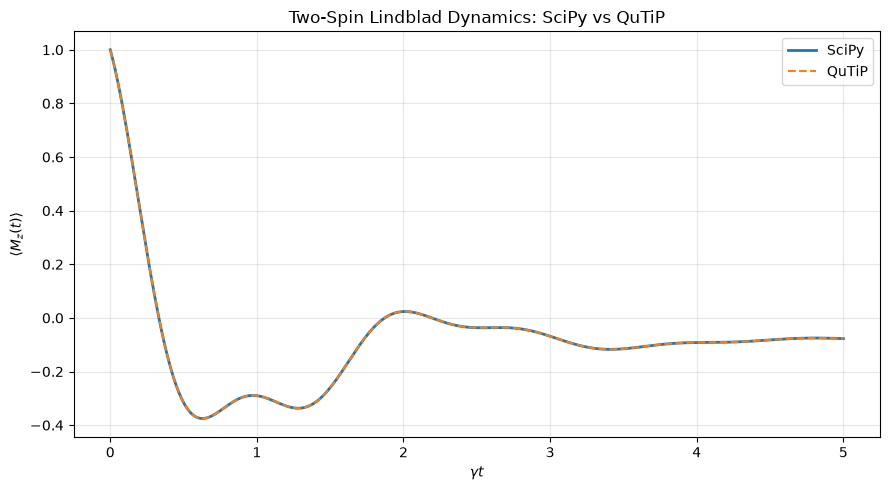

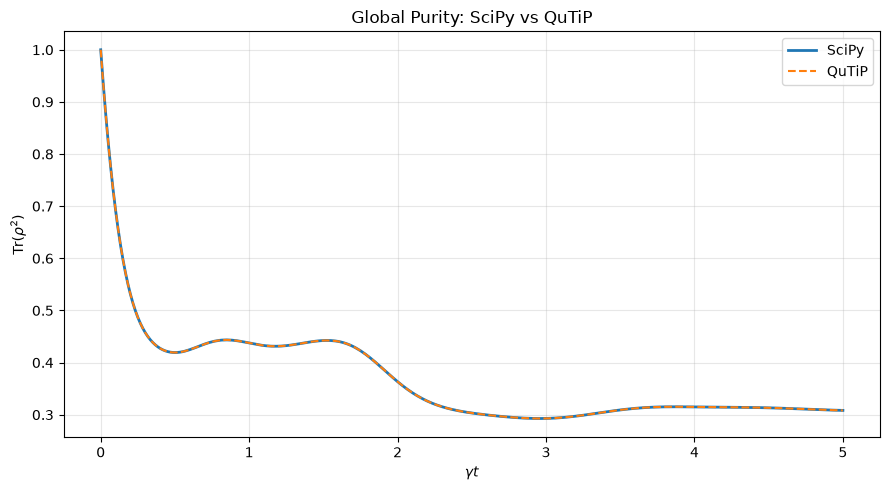

In [6]:

# EXERCISE 3.5: QUTIP IMPLEMENTATION

import qutip as qt

# --------------------------------------------------
# 1. Convert NumPy matrices into QuTiP quantum objects
# --------------------------------------------------

# The dimensions describe two spin-1/2 subsystems.
two_spin_dims = [[2, 2], [2, 2]]

H_q = qt.Qobj(H2, dims=two_spin_dims)
rho0_q = qt.Qobj(rho0, dims=two_spin_dims)
Mz_q = qt.Qobj(Mz, dims=two_spin_dims)

collapse_ops_q = [
    qt.Qobj(L_op, dims=two_spin_dims)
    for L_op in collapse_ops
]

print("QuTiP version:", qt.__version__)
print("Hamiltonian dimensions:", H_q.dims)
print("Number of collapse operators:", len(collapse_ops_q))


# --------------------------------------------------
# 2. Solve the Lindblad master equation
# --------------------------------------------------

result_35 = qt.mesolve(
    H_q,
    rho0_q,
    times_34,
    c_ops=collapse_ops_q,
    e_ops=[Mz_q],
    options={
        "rtol": 1e-10,
        "atol": 1e-12,
        "store_states": True,
        "normalize_output": False
    }
)

# Magnetisation from QuTiP's expectation-value solver
mz_qutip_35 = np.array(result_35.expect[0]).real

# Extract the full density-matrix trajectory
rho_qutip_35 = np.array([
    state.full() for state in result_35.states
])


# --------------------------------------------------
# 3. Calculate purity and validate physical properties
# --------------------------------------------------

purity_qutip_35 = np.array([
    np.trace(rho @ rho).real
    for rho in rho_qutip_35
])

trace_errors_35 = np.array([
    abs(np.trace(rho) - 1)
    for rho in rho_qutip_35
])

hermiticity_errors_35 = np.array([
    np.linalg.norm(rho - rho.conj().T)
    for rho in rho_qutip_35
])

minimum_eigenvalue_35 = min(
    np.linalg.eigvalsh(rho).min()
    for rho in rho_qutip_35
)


# --------------------------------------------------
# 4. Compare QuTiP against our SciPy implementation
# --------------------------------------------------

# Compare magnetisation at every time point
magnetisation_errors = np.abs(
    mz_qutip_35 - mz_open_34
)

# Compare global purity
purity_errors = np.abs(
    purity_qutip_35 - purity_open_34
)

# Compare the complete density matrices
density_matrix_errors = np.array([
    np.linalg.norm(rho_q - rho_s)
    for rho_q, rho_s in zip(
        rho_qutip_35, rho_trajectory
    )
])

max_mz_error = np.max(magnetisation_errors)
max_purity_error = np.max(purity_errors)
max_rho_error = np.max(density_matrix_errors)


# --------------------------------------------------
# 5. Print numerical results
# --------------------------------------------------

print("\nINITIAL CONDITIONS")
print("Initial magnetisation:", mz_qutip_35[0])
print("Initial global purity:", purity_qutip_35[0])

print("\nFINAL STATE")
print("Final magnetisation (SciPy):", mz_open_34[-1])
print("Final magnetisation (QuTiP):", mz_qutip_35[-1])

print("Final purity (SciPy):", purity_open_34[-1])
print("Final purity (QuTiP):", purity_qutip_35[-1])

print("\nNUMERICAL COMPARISON")
print("Maximum magnetisation difference:", max_mz_error)
print("Maximum purity difference:", max_purity_error)
print("Maximum density-matrix difference:", max_rho_error)

print("\nPHYSICAL VALIDATION")
print("Maximum trace error:", np.max(trace_errors_35))
print("Maximum Hermiticity error:", np.max(hermiticity_errors_35))
print("Minimum density-matrix eigenvalue:",
      minimum_eigenvalue_35)


# --------------------------------------------------
# 6. Final validation assertions
# --------------------------------------------------

assert len(rho_qutip_35) == len(times_34)

assert np.max(trace_errors_35) < 1e-8
assert np.max(hermiticity_errors_35) < 1e-8
assert minimum_eigenvalue_35 > -1e-8

assert max_mz_error < 1e-7
assert max_purity_error < 1e-7
assert max_rho_error < 1e-7

print("\nAll validation checks passed.")


# --------------------------------------------------
# 7. Plot magnetisation: SciPy versus QuTiP
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    gamma * times_34,
    mz_open_34,
    label="SciPy",
    linewidth=2
)

plt.plot(
    gamma * times_34,
    mz_qutip_35,
    "--",
    label="QuTiP",
    linewidth=1.5
)

plt.xlabel(r"$\gamma t$")
plt.ylabel(r"$\langle M_z(t)\rangle$")
plt.title("Two-Spin Lindblad Dynamics: SciPy vs QuTiP")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 8. Plot global purity: SciPy versus QuTiP
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    gamma * times_34,
    purity_open_34,
    label="SciPy",
    linewidth=2
)

plt.plot(
    gamma * times_34,
    purity_qutip_35,
    "--",
    label="QuTiP",
    linewidth=1.5
)

plt.xlabel(r"$\gamma t$")
plt.ylabel(r"$\mathrm{Tr}(\rho^2)$")
plt.title("Global Purity: SciPy vs QuTiP")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

3.6 Dissipation Strength and Final Validation

We investigate the competition between coherent quantum dynamics and environmental dissipation by varying the decay rate in our two-spin transverse-Ising model.

Using QuTiP, we calculate the time evolution of magnetisation and global purity for several dissipation strengths. We compare the results against our validated closed-system and SciPy solutions, while verifying trace preservation, Hermiticity and positivity.

This investigation establishes how environmental coupling changes the system's dynamics and provides a validated numerical reference for reproducing the results of Jo and Kim.

DISSIPATION STRENGTH COMPARISON

Gamma         Final Mz    Final Purity    Initial Slope
0.00          0.870304        1.000000         0.000000
0.20          0.109167        0.268343        -0.400000
0.50         -0.077286        0.308297        -1.000000
1.00         -0.257681        0.449010        -2.000000
2.00         -0.538461        0.715975        -4.000000

FINAL VALIDATION
Closed-system magnetisation error: 1.8338008889173807e-10
Closed-system purity error: 1.7801824458985038e-09
Gamma=0.5 magnetisation error: 4.3489822854070326e-11
Gamma=0.5 purity error: 1.9255319561040096e-11
Gamma=0.5 density-matrix error: 1.7130186634637914e-10

All validation checks passed.


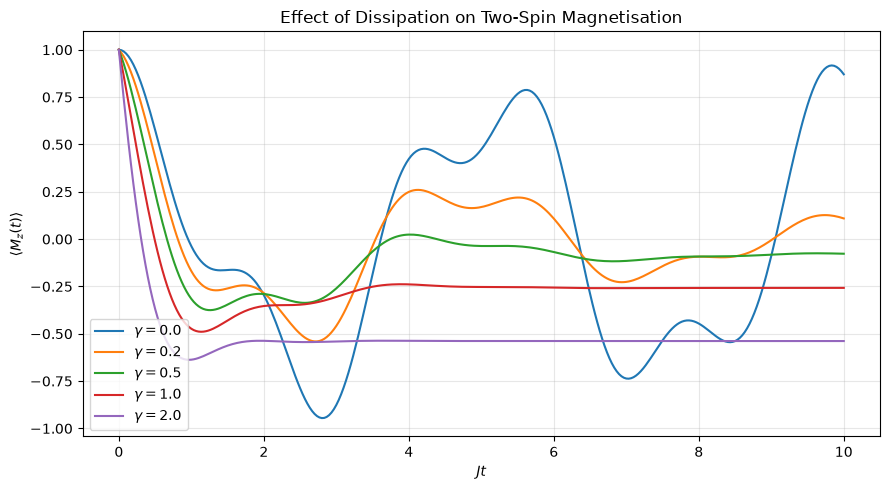

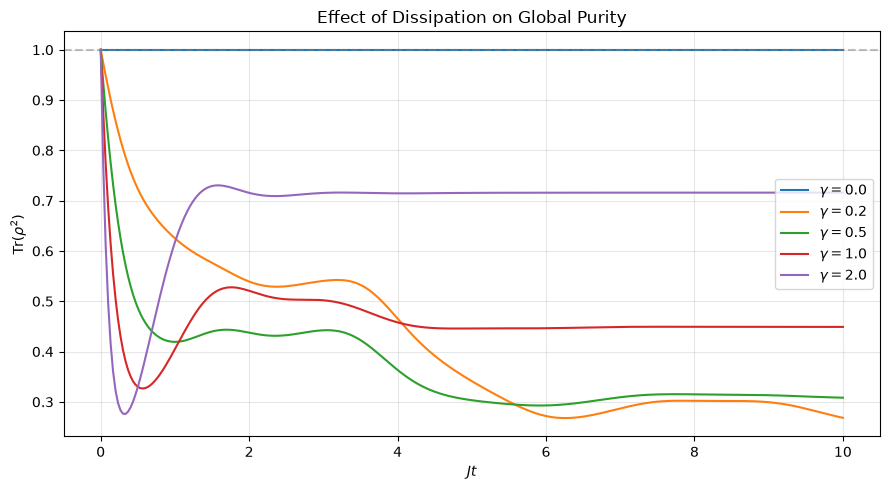

In [7]:

# EXERCISE 3.6: DISSIPATION STRENGTH AND FINAL VALIDATION

# --------------------------------------------------
# 1. Define the decay rates and time interval
# --------------------------------------------------

decay_rates = [0.0, 0.2, 0.5, 1.0, 2.0]

times_36 = times_34

# Unscaled decay operators
sm1_q = qt.Qobj(
    np.kron(sigma_minus, I),
    dims=[[2, 2], [2, 2]]
)

sm2_q = qt.Qobj(
    np.kron(I, sigma_minus),
    dims=[[2, 2], [2, 2]]
)

# Store all numerical results for later use
sweep_36 = {}


# --------------------------------------------------
# 2. Solve the Lindblad equation for each decay rate
# --------------------------------------------------

for rate in decay_rates:

    # Construct the collapse operators
    c_ops = [
        np.sqrt(rate) * sm1_q,
        np.sqrt(rate) * sm2_q
    ] if rate > 0 else []

    # Solve the master equation
    result = qt.mesolve(
        H_q,
        rho0_q,
        times_36,
        c_ops=c_ops,
        e_ops=[Mz_q],
        options={
            "rtol": 1e-10,
            "atol": 1e-12,
            "store_states": True,
            "normalize_output": False
        }
    )

    # Extract the density-matrix trajectory
    rho_states = np.array([
        state.full() for state in result.states
    ])

    # Calculate magnetisation
    mz = np.asarray(result.expect[0]).real

    # Calculate global purity
    purity = np.array([
        np.trace(rho @ rho).real
        for rho in rho_states
    ])

    # Check trace preservation
    trace_error = max(
        abs(np.trace(rho) - 1)
        for rho in rho_states
    )

    # Check Hermiticity
    hermiticity_error = max(
        np.linalg.norm(rho - rho.conj().T)
        for rho in rho_states
    )

    # Check positivity
    min_eigenvalue = min(
        np.linalg.eigvalsh(
            (rho + rho.conj().T) / 2
        ).min()
        for rho in rho_states
    )

    # Calculate the initial derivative analytically
    c_matrices = [
        np.sqrt(rate) * np.kron(sigma_minus, I),
        np.sqrt(rate) * np.kron(I, sigma_minus)
    ]

    drho0 = -1j * (H2 @ rho0 - rho0 @ H2)

    for L_op in c_matrices:
        LdagL = L_op.conj().T @ L_op

        drho0 += (
            L_op @ rho0 @ L_op.conj().T
            - 0.5 * (LdagL @ rho0 + rho0 @ LdagL)
        )

    initial_slope = np.trace(drho0 @ Mz).real

    # Save results
    sweep_36[rate] = {
        "rho": rho_states,
        "magnetisation": mz,
        "purity": purity,
        "trace_error": trace_error,
        "hermiticity_error": hermiticity_error,
        "min_eigenvalue": min_eigenvalue,
        "initial_slope": initial_slope
    }


# --------------------------------------------------
# 3. Print a summary of all simulations
# --------------------------------------------------

print("DISSIPATION STRENGTH COMPARISON\n")

print(
    f"{'Gamma':<8}"
    f"{'Final Mz':>14}"
    f"{'Final Purity':>16}"
    f"{'Initial Slope':>17}"
)

for rate, data in sweep_36.items():
    print(
        f"{rate:<8.2f}"
        f"{data['magnetisation'][-1]:>14.6f}"
        f"{data['purity'][-1]:>16.6f}"
        f"{data['initial_slope']:>17.6f}"
    )


# --------------------------------------------------
# 4. Final numerical validation
# --------------------------------------------------

for rate, data in sweep_36.items():

    assert data["trace_error"] < 1e-8

    assert data["hermiticity_error"] < 1e-8

    assert data["min_eigenvalue"] > -1e-7

    assert np.allclose(
        data["initial_slope"],
        -2 * rate,
        atol=1e-10
    )

# Check gamma = 0 against exact closed-system dynamics
closed_error = np.max(
    np.abs(
        sweep_36[0.0]["magnetisation"] - mz_closed_34
    )
)

closed_purity_error = np.max(
    np.abs(sweep_36[0.0]["purity"] - 1)
)

# Check gamma = 0.5 against our SciPy solution
mz_reference_error = np.max(
    np.abs(
        sweep_36[0.5]["magnetisation"] - mz_open_34
    )
)

purity_reference_error = np.max(
    np.abs(
        sweep_36[0.5]["purity"] - purity_open_34
    )
)

rho_reference_error = max(
    np.linalg.norm(rho_q - rho_s)
    for rho_q, rho_s in zip(
        sweep_36[0.5]["rho"],
        rho_trajectory
    )
)

print("\nFINAL VALIDATION")
print("Closed-system magnetisation error:",
      closed_error)
print("Closed-system purity error:",
      closed_purity_error)

print("Gamma=0.5 magnetisation error:",
      mz_reference_error)
print("Gamma=0.5 purity error:",
      purity_reference_error)
print("Gamma=0.5 density-matrix error:",
      rho_reference_error)

assert closed_error < 1e-7
assert closed_purity_error < 1e-7

assert mz_reference_error < 1e-7
assert purity_reference_error < 1e-7
assert rho_reference_error < 1e-7

print("\nAll validation checks passed.")


# --------------------------------------------------
# 5. Plot magnetisation for each decay rate
# --------------------------------------------------

plt.figure(figsize=(9, 5))

for rate, data in sweep_36.items():

    plt.plot(
        J * times_36,
        data["magnetisation"],
        label=fr"$\gamma={rate}$"
    )

plt.xlabel(r"$Jt$")
plt.ylabel(r"$\langle M_z(t)\rangle$")
plt.title("Effect of Dissipation on Two-Spin Magnetisation")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 6. Plot global purity for each decay rate
# --------------------------------------------------

plt.figure(figsize=(9, 5))

for rate, data in sweep_36.items():

    plt.plot(
        J * times_36,
        data["purity"],
        label=fr"$\gamma={rate}$"
    )

plt.axhline(
    1,
    linestyle="--",
    color="gray",
    alpha=0.5
)

plt.xlabel(r"$Jt$")
plt.ylabel(r"$\mathrm{Tr}(\rho^2)$")
plt.title("Effect of Dissipation on Global Purity")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()